In [5]:
# Robust Anomaly Detection Project 

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neural_network import MLPRegressor

# Step 1: Generate Synthetic Data
def generate_data(n=2000, features=10):
    t = np.arange(n)
    data = {}

    for i in range(features):
        signal = np.sin(t / 20 + i) + np.random.normal(0, 0.2, n)
        data[f"sensor_{i+1}"] = signal

    df = pd.DataFrame(data)

    # Add anomalies
    anomaly_idx = np.random.choice(n, 50, replace=False)
    df.loc[anomaly_idx] += np.random.normal(4, 1, (50, features))

    return df

df = generate_data()

# Step 2: Preprocessing
scaler = StandardScaler()
X = scaler.fit_transform(df)

X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

# Step 3: Isolation Forest
if_model = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=42
)
if_model.fit(X_train)

pred_if = if_model.predict(X_test)
pred_if = np.where(pred_if == -1, 1, 0)

# Step 4: Autoencoder Approximation using MLP
vae_model = MLPRegressor(
    hidden_layer_sizes=(32,16,32),
    max_iter=100,
    random_state=42
)

vae_model.fit(X_train, X_train)

reconstructed = vae_model.predict(X_test)

reconstruction_error = ((X_test - reconstructed) ** 2).mean(axis=1)

threshold = np.percentile(reconstruction_error, 97)

pred_vae = (reconstruction_error > threshold).astype(int)

# Step 5: Results
print("Dataset Shape:", df.shape)
print("Isolation Forest Detected Anomalies:", pred_if.sum())
print("Autoencoder Detected Anomalies:", pred_vae.sum())

# Step 6: Show Sample Data
print("\nSample Data:")
print(df.head())

Dataset Shape: (2000, 10)
Isolation Forest Detected Anomalies: 16
Autoencoder Detected Anomalies: 12

Sample Data:
   sensor_1  sensor_2  sensor_3  sensor_4  sensor_5  sensor_6  sensor_7  \
0  0.206167  0.987494  1.016834  0.069658 -0.710681 -1.208858 -0.278122   
1 -0.085049  0.870427  0.923750 -0.329863 -0.492022 -0.945802 -0.201818   
2 -0.025720  0.558061  1.035627  0.406116 -0.700081 -0.660346 -0.017133   
3  0.027250  1.032911  0.713960  0.021329 -0.977654 -0.739755  0.154210   
4 -0.110064  0.646839  0.906126 -0.332421 -1.108241 -0.617075 -0.166078   

   sensor_8  sensor_9  sensor_10  
0  0.469712  1.118627   0.780609  
1  0.776928  0.922601   0.778746  
2  1.208346  1.035609   0.061723  
3  0.738062  1.115442   0.226373  
4  0.497699  1.065287   0.283645  


C:\Users\ELCOT\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(



Isolation Forest
------------------------------
Accuracy : 0.993
Precision: 0.885
Recall   : 1.0
F1 Score : 0.939

Autoencoder
------------------------------
Accuracy : 0.973
Precision: 1.0
Recall   : 0.522
F1 Score : 0.686


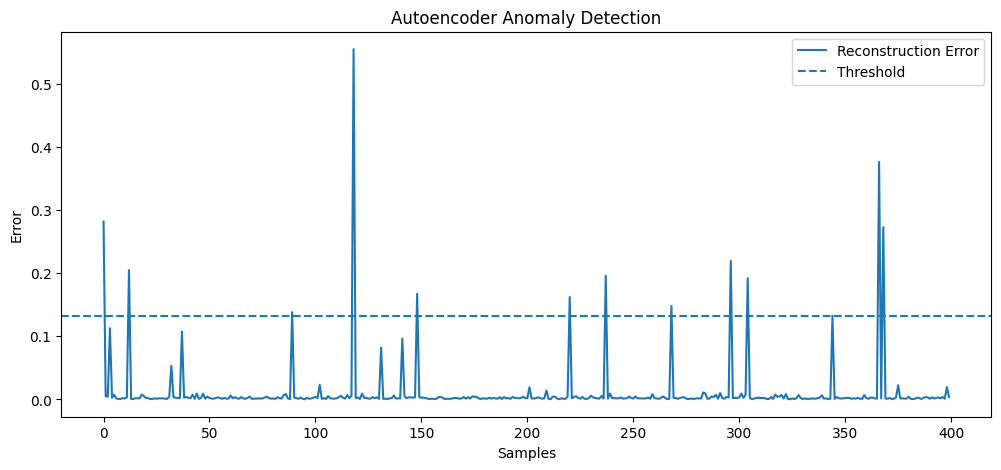


Dataset Shape: (2000, 10)
Total True Anomalies: 60
Isolation Forest Found: 26
Autoencoder Found: 12


In [6]:
#  Robust Anomaly Detection Project 

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# Generate Synthetic Data

def generate_data(n=2000, features=10):
    t = np.arange(n)
    data = {}

    for i in range(features):
        signal = np.sin(t / 20 + i) + np.random.normal(0, 0.2, n)
        data[f"sensor_{i+1}"] = signal

    df = pd.DataFrame(data)

    # True labels
    labels = np.zeros(n)

    # Inject anomalies
    anomaly_idx = np.random.choice(n, 60, replace=False)
    df.loc[anomaly_idx] += np.random.normal(4, 1, (60, features))
    labels[anomaly_idx] = 1

    return df, labels

df, y_true = generate_data()


#  Preprocessing

scaler = StandardScaler()
X = scaler.fit_transform(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_true, test_size=0.2, random_state=42
)

#  Isolation Forest

if_model = IsolationForest(
    n_estimators=300,
    contamination=0.03,
    random_state=42
)

if_model.fit(X_train)

pred_if = if_model.predict(X_test)
pred_if = np.where(pred_if == -1, 1, 0)


#  Autoencoder Approximation

vae_model = MLPRegressor(
    hidden_layer_sizes=(64,32,16,32,64),
    max_iter=500,
    random_state=42
)

vae_model.fit(X_train, X_train)

reconstructed = vae_model.predict(X_test)

error = ((X_test - reconstructed) ** 2).mean(axis=1)

threshold = np.percentile(error, 97)

pred_vae = (error > threshold).astype(int)


#  Metrics Function

def show_metrics(name, y_true, y_pred):
    print(f"\n{name}")
    print("-" * 30)
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 3))
    print("Precision:", round(precision_score(y_true, y_pred), 3))
    print("Recall   :", round(recall_score(y_true, y_pred), 3))
    print("F1 Score :", round(f1_score(y_true, y_pred), 3))

show_metrics("Isolation Forest", y_test, pred_if)
show_metrics("Autoencoder", y_test, pred_vae)

#  Plot Reconstruction Error
plt.figure(figsize=(12,5))
plt.plot(error, label="Reconstruction Error")
plt.axhline(threshold, linestyle="--", label="Threshold")
plt.title("Autoencoder Anomaly Detection")
plt.xlabel("Samples")
plt.ylabel("Error")
plt.legend()
plt.show()


#  Final Output

print("\nDataset Shape:", df.shape)
print("Total True Anomalies:", int(y_true.sum()))
print("Isolation Forest Found:", pred_if.sum())
print("Autoencoder Found:", pred_vae.sum())